# $\text{MA}(q)$ with Offset

$\text{MA}(q)$ with a constant offset is defined by,

$
\begin{equation}
X_t = \mu^* + \sigma \varepsilon_t + \sum_{i=1}^q \theta_i \sigma \varepsilon_{t-i}
\end{equation}
\tag{1}
$

where, $\varepsilon \sim \text{Normal}(0,1)$

An $\text{MA}(q)$ process is stationary for any $\theta_i$, and the offset enters
additively without passing through the moving average, so

$
\begin{align}
&\text{E}(X_t) = \mu^* \\
&\text{Var}(X_t) = \sigma^2 \left( 1 + \sum_{i=1}^q \theta_i^2 \right)
\end{align}
\tag{2}
$

It follows that $X_t$ has distribution,

$
\begin{align}
X_t \sim \text{Normal}\left( \mu^*, \sigma^2 \left( 1 + \sum_{i=1}^q \theta_i^2 \right) \right)
\end{align}
\tag{3}
$

## Contrast with $\text{AR}(p)$ with Offset

This is where $\text{MA}(q)$ differs from the $\text{AR}(1)$ case, and the difference
matters when reading an estimation result. For $\text{AR}(1)$,

$
\begin{align}
X_t = \varphi X_{t-1} + \mu^* + \sigma \varepsilon_t
\quad\Longrightarrow\quad
\lim_{t \to \infty}\text{E}(X_t) = \frac{\mu^*}{1 - \varphi}
\end{align}
\tag{4}
$

so the mean and the offset are different numbers, related by $1/(1 - \varphi)$. For
$\text{MA}(q)$ they coincide.

`statsmodels` fits both with `trend='c'` and reports the process **mean** as its
constant. For $\text{MA}(q)$ that constant is $\mu^*$ already; for $\text{AR}(p)$
it is $\mu^*/(1-\varphi)$ and must be converted. The estimation section below
simulates a known $\mu^*$ and reads it back, which is the comparison to make
against `ar1_with_offset.ipynb`.

There is no `create_ma_offset_source` in the library — the $\text{AR}$ case has one,
the $\text{MA}$ case does not — so the series here is built by adding $\mu^*$ to
`create_ma_source`, exact for the reason above.

## Imports

In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
import numpy
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import arima, stats
from lib.plots import stack, fcurve, curve
from lib.utils import create_parameter_scan

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [2]:
σ = 1.0
nsample = 1000

def ma_offset_source(θ, μ, σ, npts):
    """MA(q) with a constant offset. The offset does not pass through the moving
    average, so adding it to a zero mean MA(q) is exact."""
    t, ma = arima.create_ma_source(θ=θ, σ=σ, npts=npts)
    return t, ma + μ

def comparison_plot_θ(θ_vals, μ, σ, ylim, title):
    labels = [f"θ={val}" for val in θ_vals]
    scan = [ma_offset_source(θ, μ, σ, nsample)[1] for θ in θ_vals]
    t = numpy.arange(nsample, dtype=float)
    stack(scan, [t]*len(scan), ylim=ylim, title=title, labels=labels,
          ylabels=r"$S_t$", xlabel="Time", figsize=(10, 6), lw=1)

def comparison_plot_μ(θ, μ_vals, σ, ylim, title):
    labels = [r"$\mu^*$" + f"={val}" for val in μ_vals]
    scan = [ma_offset_source(θ, μ, σ, nsample)[1] for μ in μ_vals]
    t = numpy.arange(nsample, dtype=float)
    stack(scan, [t]*len(scan), ylim=ylim, title=title, labels=labels,
          ylabels=r"$S_t$", xlabel="Time", figsize=(10, 6), lw=1)

def cumu_mean_plot(θ, σ, μ, nsample):
    title = f"Convergence of Simulation Mean to $t\\rightarrow\\infty$ Limit: " \
            f"$\\theta=${θ}, $\\sigma=${σ}, $\\mu^*=${μ}"
    t, ma = ma_offset_source(θ, μ, σ, nsample)
    _, cumu_mean = stats.compute_cumu_mean(t, ma)
    fcurve(data=cumu_mean, func=numpy.full(len(t), float(μ)), x=t, fx=t, title_offset=0.025,
           xlabel=r"$t$", ylabel=r"$\mu_t$",
           labels=["Simulation", r"$\mu_t\rightarrow \mu^*$"], title=title)

def cumu_sd_plot(θ, σ, μ, nsample):
    title = f"Convergence of Simulation Standard Deviation to $t\\rightarrow\\infty$ Limit: " \
            f"$\\theta=${θ}, $\\sigma=${σ}, $\\mu^*=${μ}"
    t, ma = ma_offset_source(θ, μ, σ, nsample)
    _, cumu_sd = stats.compute_cumu_sd(t, ma)
    _, ma_sd = arima.compute_maq_sd(θ=θ, σ=σ, npts=len(t))
    fcurve(data=cumu_sd, func=ma_sd, x=t, fx=t, title_offset=0.025,
           xlabel=r"$t$", ylabel=r"$\sigma_t$",
           labels=["Simulation", r"$\sigma_t\rightarrow \sigma\sqrt{1 + \sum_i \theta_i^2}$"],
           title=title)

## Simulation $\theta$ Scan

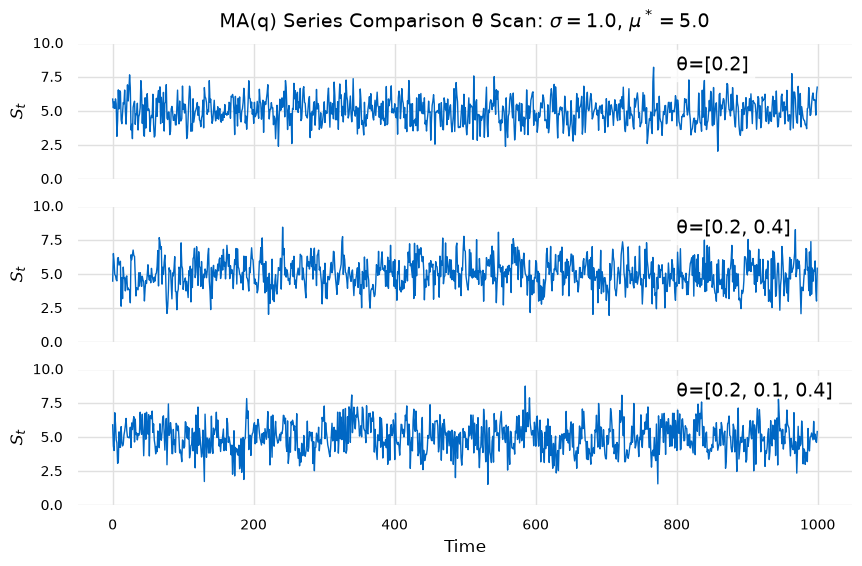

In [3]:
μ = 5.0
title = f"MA(q) Series Comparison θ Scan: $σ={σ}$, $μ^*={μ}$"
θ_vals = [[0.2], [0.2, 0.4], [0.2, 0.1, 0.4]]
comparison_plot_θ(θ_vals, μ, σ, (0.0, 10.0), title)

## Simulation $\mu^*$ Scan

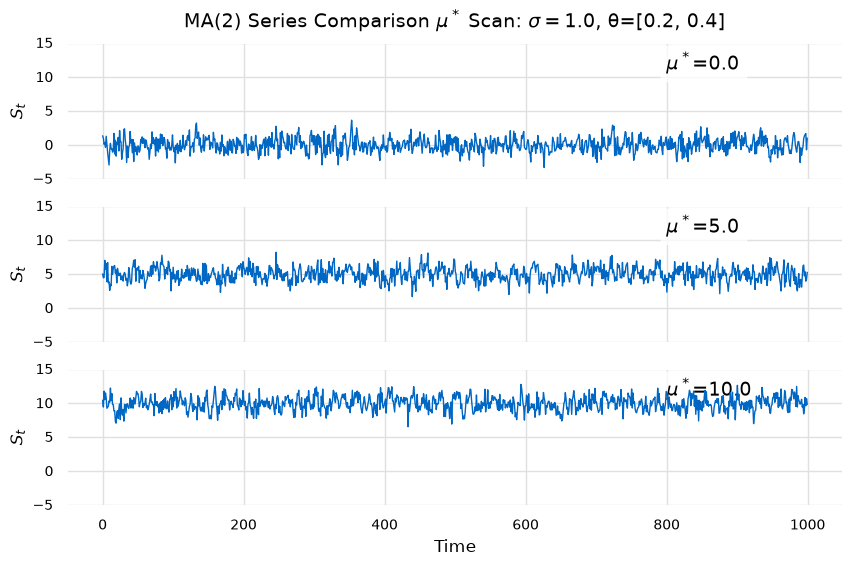

In [4]:
θ = [0.2, 0.4]
title = f"MA(2) Series Comparison " + r"$\mu^*$" + f" Scan: $σ={σ}$, θ={θ}"
μ_vals = [0.0, 5.0, 10.0]
comparison_plot_μ(θ, μ_vals, σ, (-5.0, 15.0), title)

## Mean

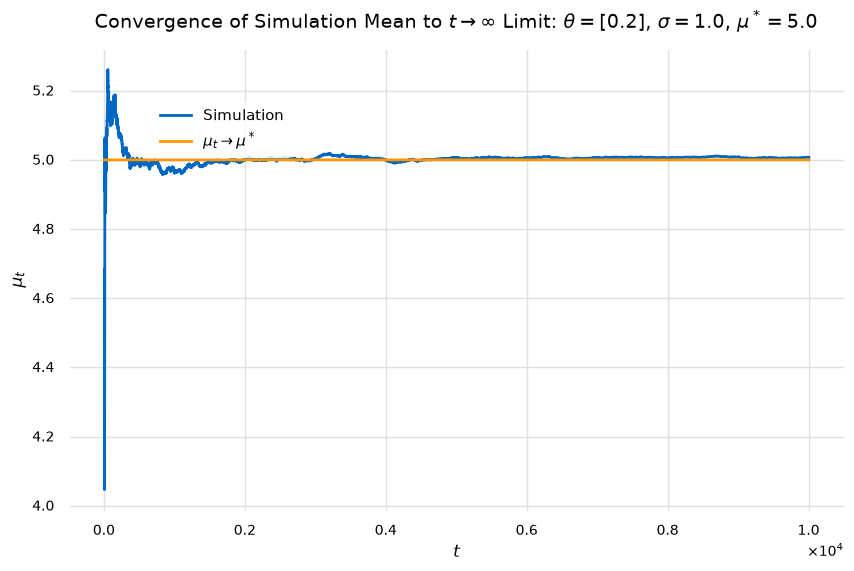

In [5]:
nsample = 10000
cumu_mean_plot([0.2], 1.0, 5.0, nsample)

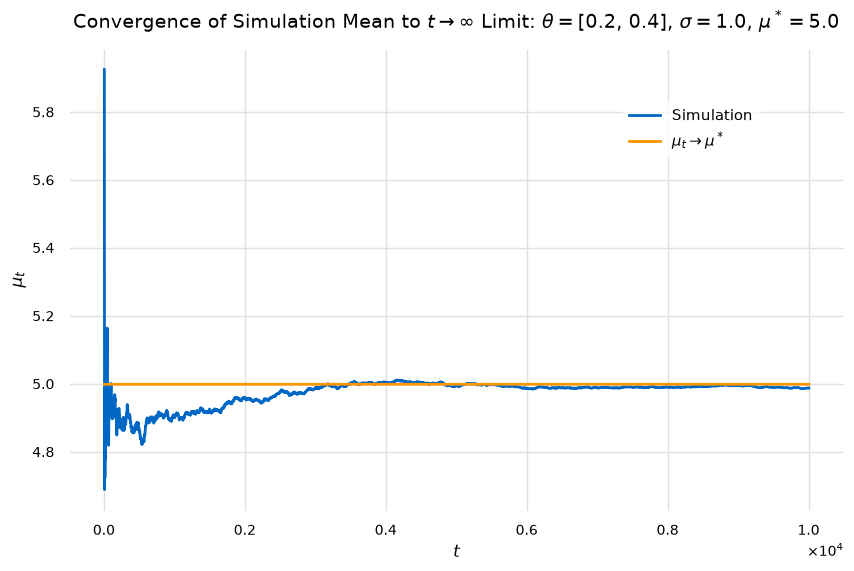

In [6]:
cumu_mean_plot([0.2, 0.4], 1.0, 5.0, nsample)

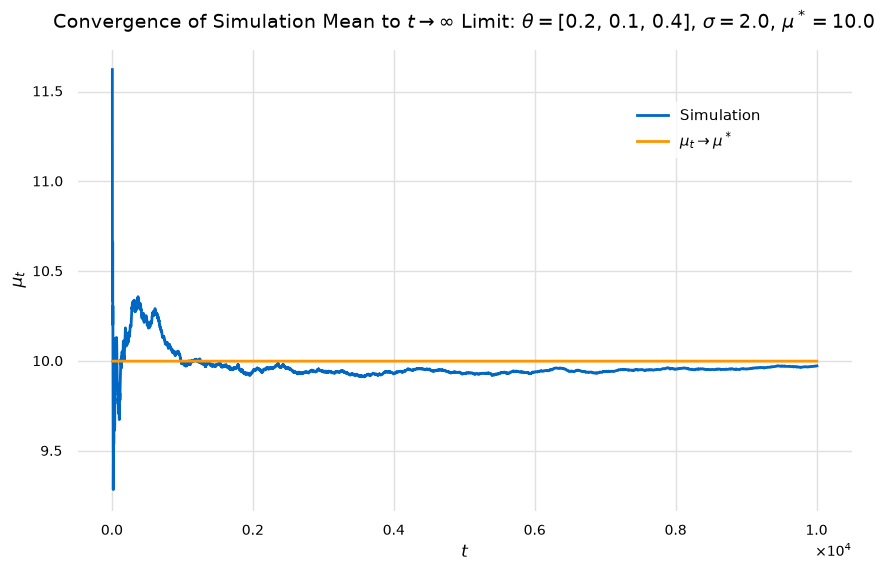

In [7]:
cumu_mean_plot([0.2, 0.1, 0.4], 2.0, 10.0, nsample)

## Standard Deviation

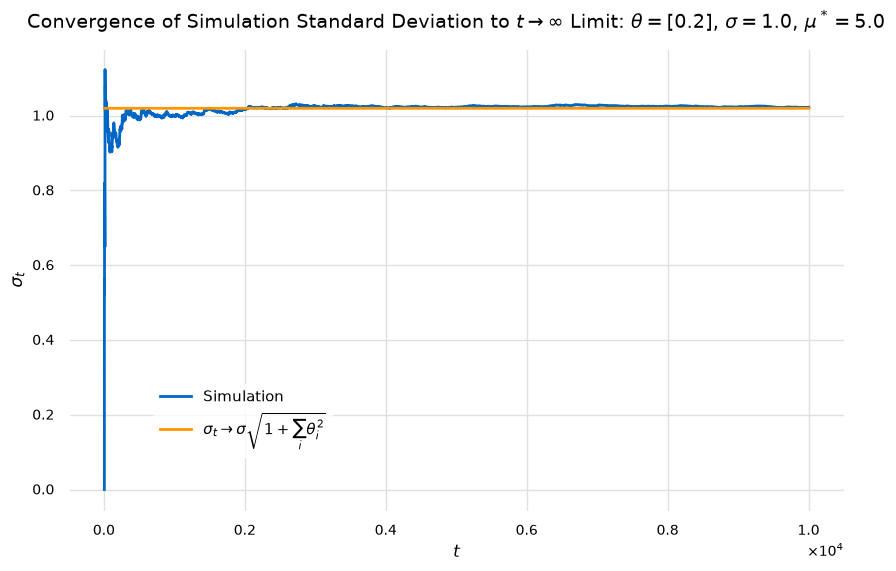

In [8]:
cumu_sd_plot([0.2], 1.0, 5.0, nsample)

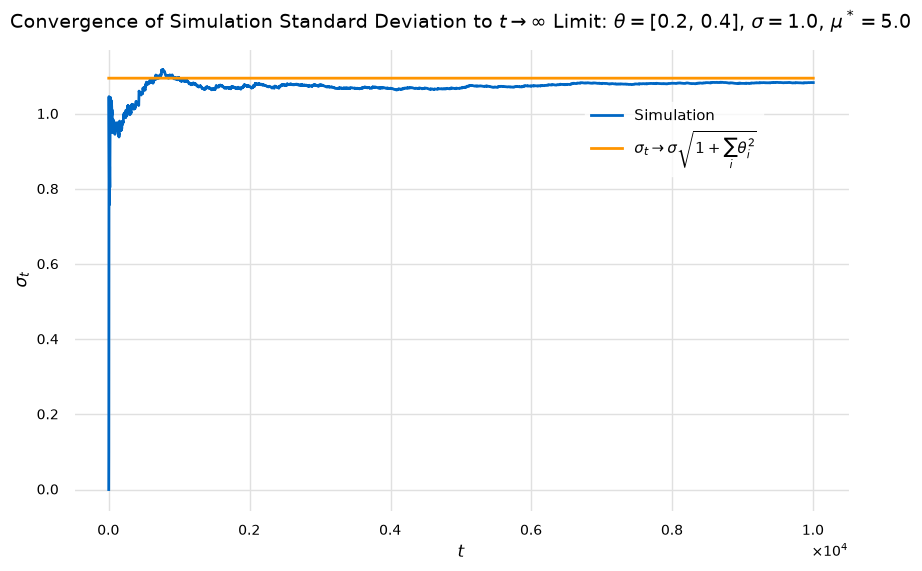

In [9]:
cumu_sd_plot([0.2, 0.4], 1.0, 5.0, nsample)

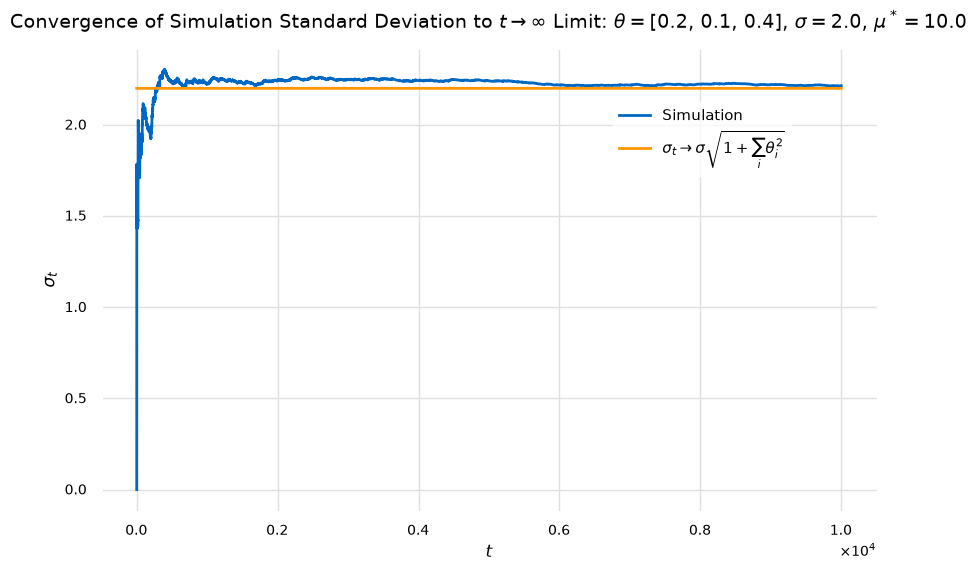

In [10]:
cumu_sd_plot([0.2, 0.1, 0.4], 2.0, 10.0, nsample)

## Parameter Estimation

### $\text{MA}(1)$ Example ($\theta = [0.5]$, $\mu^* = 5.0$)

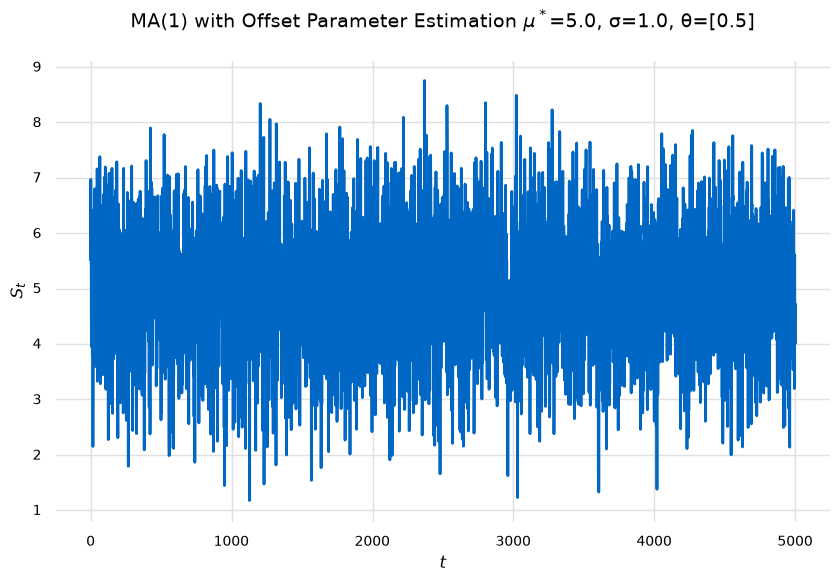

In [11]:
numpy.random.seed(20260830)
θ = [0.5]
μ = 5.0
σ = 1.0
nsample = 5000
t, ma = ma_offset_source(θ, μ, σ, nsample)
title = f"MA(1) with Offset Parameter Estimation $\\mu^*$={μ}, σ={σ}, θ={θ}"
curve(ma, t, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

In [12]:
result, result_model = arima.compute_ma_offset_estimate(ma, order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 5000
Model:                 ARIMA(0, 0, 1)   Log Likelihood               -7075.033
Date:                Sun, 30 Aug 2026   AIC                          14156.066
Time:                        11:23:19   BIC                          14175.617
Sample:                             0   HQIC                         14162.918
                               - 5000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.9634      0.021    234.322      0.000       4.922       5.005
ma.L1          0.5026      0.012     41.449      0.000       0.479       0.526
sigma2         0.9921      0.020     49.644      0.000       0.953       1.031
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):                 1.42
Prob(Q):                              0.83   Prob(JB):                         0.49
Heteroskedasticity (H):               0.94   Skew:                            -0.04
Prob(H) (two-sided):                  0.23   Kurtosis:                         2.97
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [13]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "MA_OFFSET",
   "trend": "c",
   "const": {
      "est": 4.963442823095461,
      "err": 0.02118212323489206,
      "est_label": "$\\hat{\\mu}$",
      "err_label": "$\\sigma_{\\hat{\\mu}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "e71b8839-06af-4858-9f0b-de9610f66a07",
      "param_type": "ARMA_CONST"
   },
   "order": 1,
   "params": [
      {
         "est": 0.5025881373969814,
         "err": 0.012125330956131709,
         "est_label": "$\\hat{\\theta_{1}}$",
         "err_label": "$\\sigma_{\\hat{\\theta_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "e71b8839-06af-4858-9f0b-de9610f66a07",
         "param_type": "ARMA_PARAM"
      }
   ],
   "sigma2": {
      "est": 0.9921004924323318,
      "err": 0.019984190973635654,
      "est_label": "$\\hat{\\sigma^2}$",
      "err_label": "$\\sigma_{\\hat{\\sigma^2}}$",
      "row": 0,
      "column": 0,
      "order": 0,
 

In [14]:
# For MA(q) the process mean IS the offset, so the reported constant needs no
# conversion. Compare with ar1_with_offset.ipynb, where the same field holds
# mu*/(1 - phi) and is off from mu* by that factor.
print(f"sample mean      = {ma.mean():.4f}")
print(f"reported const   = {result_model.const.est:.4f}   labelled {result_model.const.est_label}")
print(f"true mu*         = {μ}")

sample mean      = 4.9634
reported const   = 4.9634   labelled $\hat{\mu}$
true mu*         = 5.0


### $\text{MA}(2)$ Example ($\theta = [0.2, 0.4]$, $\mu^* = 10.0$)

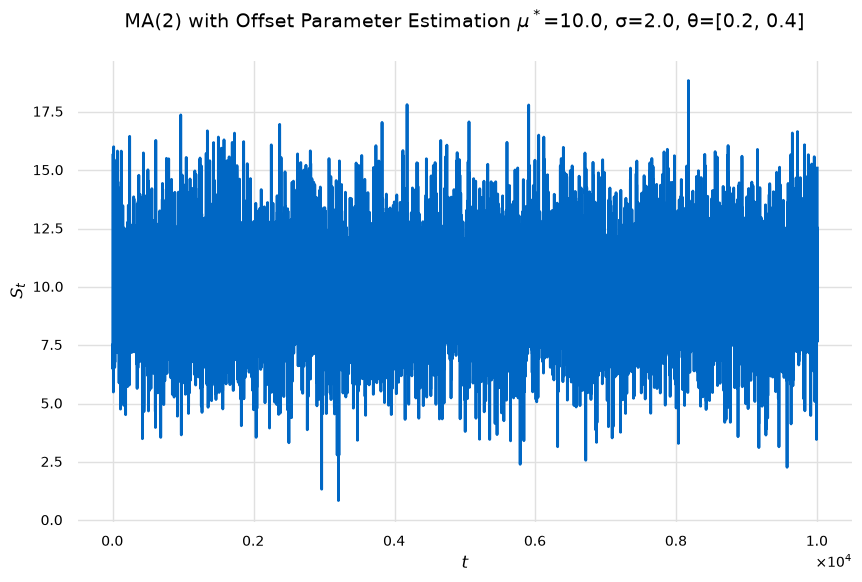

In [15]:
numpy.random.seed(20260831)
θ = [0.2, 0.4]
μ = 10.0
σ = 2.0
nsample = 10000
t, ma = ma_offset_source(θ, μ, σ, nsample)
title = f"MA(2) with Offset Parameter Estimation $\\mu^*$={μ}, σ={σ}, θ={θ}"
curve(ma, t, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

In [16]:
result, result_model = arima.compute_ma_offset_estimate(ma, order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                10000
Model:                 ARIMA(0, 0, 2)   Log Likelihood              -21151.243
Date:                Sun, 30 Aug 2026   AIC                          42310.487
Time:                        11:23:19   BIC                          42339.328
Sample:                             0   HQIC                         42320.249
                              - 10000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.0025      0.032    310.786      0.000       9.939      10.066
ma.L1          0.2027      0.009     21.830      0.000       0.185       0.221
ma.L2          0.4010      0.009     43.154      0.000       0.383       0.419
sigma2         4.0243      0.057     71.018      0.000       3.913       4.135
===================================================================================
Ljung-Box (L1) (Q):                   0.10   Jarque-Bera (JB):                 1.61
Prob(Q):                              0.75   Prob(JB):                         0.45
Heteroskedasticity (H):               0.96   Skew:                            -0.03
Prob(H) (two-sided):                  0.22   Kurtosis:                         3.02
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [17]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "MA_OFFSET",
   "trend": "c",
   "const": {
      "est": 10.00254476986748,
      "err": 0.032184678350272264,
      "est_label": "$\\hat{\\mu}$",
      "err_label": "$\\sigma_{\\hat{\\mu}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "e13d8160-ad40-4d1a-b527-da2be5b81e9b",
      "param_type": "ARMA_CONST"
   },
   "order": 2,
   "params": [
      {
         "est": 0.20273007715413954,
         "err": 0.00928680382380317,
         "est_label": "$\\hat{\\theta_{1}}$",
         "err_label": "$\\sigma_{\\hat{\\theta_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "e13d8160-ad40-4d1a-b527-da2be5b81e9b",
         "param_type": "ARMA_PARAM"
      },
      {
         "est": 0.4010298890403716,
         "err": 0.009293047433075623,
         "est_label": "$\\hat{\\theta_{2}}$",
         "err_label": "$\\sigma_{\\hat{\\theta_{2}}}$",
         "row": 0,
         "column": 0,
        

In [18]:
# For MA(q) the process mean IS the offset, so the reported constant needs no
# conversion. Compare with ar1_with_offset.ipynb, where the same field holds
# mu*/(1 - phi) and is off from mu* by that factor.
print(f"sample mean      = {ma.mean():.4f}")
print(f"reported const   = {result_model.const.est:.4f}   labelled {result_model.const.est_label}")
print(f"true mu*         = {μ}")

sample mean      = 10.0025
reported const   = 10.0025   labelled $\hat{\mu}$
true mu*         = 10.0


### $\text{MA}(3)$ Example ($\theta = [0.2, 0.1, 0.4]$, $\mu^* = -3.0$)

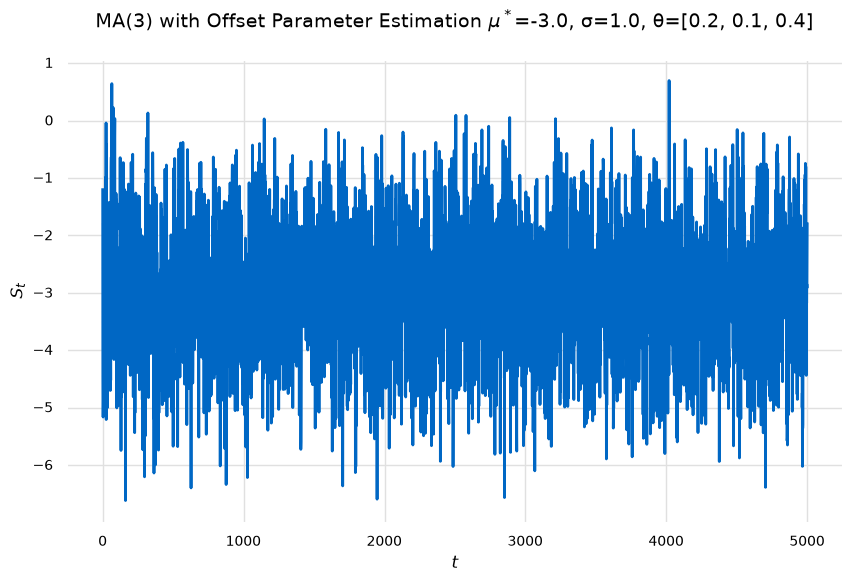

In [19]:
numpy.random.seed(20260832)
θ = [0.2, 0.1, 0.4]
μ = -3.0
σ = 1.0
nsample = 5000
t, ma = ma_offset_source(θ, μ, σ, nsample)
title = f"MA(3) with Offset Parameter Estimation $\\mu^*$={μ}, σ={σ}, θ={θ}"
curve(ma, t, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

In [20]:
result, result_model = arima.compute_ma_offset_estimate(ma, order=3)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 5000
Model:                 ARIMA(0, 0, 3)   Log Likelihood               -7060.255
Date:                Sun, 30 Aug 2026   AIC                          14130.511
Time:                        11:23:19   BIC                          14163.097
Sample:                             0   HQIC                         14141.932
                               - 5000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.0145      0.024   -127.076      0.000      -3.061      -2.968
ma.L1          0.2041      0.013     15.694      0.000       0.179       0.230
ma.L2          0.0958      0.013      7.235      0.000       0.070       0.122
ma.L3          0.3887      0.013     29.364      0.000       0.363       0.415
sigma2         0.9862      0.020     49.949      0.000       0.948       1.025
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 0.11
Prob(Q):                              0.93   Prob(JB):                         0.95
Heteroskedasticity (H):               0.98   Skew:                             0.01
Prob(H) (two-sided):                  0.67   Kurtosis:                         3.00
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [21]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "MA_OFFSET",
   "trend": "c",
   "const": {
      "est": -3.0144920616164117,
      "err": 0.02372187583246838,
      "est_label": "$\\hat{\\mu}$",
      "err_label": "$\\sigma_{\\hat{\\mu}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "0c2012b9-82ea-4f20-906d-368bb6d2b80f",
      "param_type": "ARMA_CONST"
   },
   "order": 3,
   "params": [
      {
         "est": 0.20409799554088534,
         "err": 0.013005128215478444,
         "est_label": "$\\hat{\\theta_{1}}$",
         "err_label": "$\\sigma_{\\hat{\\theta_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "0c2012b9-82ea-4f20-906d-368bb6d2b80f",
         "param_type": "ARMA_PARAM"
      },
      {
         "est": 0.09578101997255317,
         "err": 0.013239458036288072,
         "est_label": "$\\hat{\\theta_{2}}$",
         "err_label": "$\\sigma_{\\hat{\\theta_{2}}}$",
         "row": 0,
         "column": 0,
     

In [22]:
# For MA(q) the process mean IS the offset, so the reported constant needs no
# conversion. Compare with ar1_with_offset.ipynb, where the same field holds
# mu*/(1 - phi) and is off from mu* by that factor.
print(f"sample mean      = {ma.mean():.4f}")
print(f"reported const   = {result_model.const.est:.4f}   labelled {result_model.const.est_label}")
print(f"true mu*         = {μ}")

sample mean      = -3.0150
reported const   = -3.0145   labelled $\hat{\mu}$
true mu*         = -3.0
